# Step 3 – Exploratory Data Analysis
## Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Cleaned_Sales_Data.csv')
df.head()

,Date,Product,Region,Quantity,Category,Unit_Price,Sales,Profit
0,2025-04-13,Laptop,West,2,Electronics,55000,110000,10624.42
1,2025-12-15,Tablet,South,7,Electronics,22000,154000,34886.82
2,2025-09-28,Printer,South,5,Office,15000,75000,11867.07
3,2025-04-17,Keyboard,North,5,Accessories,1500,7500,1555.34
4,2025-03-13,Monitor,West,6,Electronics,12000,72000,9316.79


## Basic Data Information


In [4]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nSummary Statistics:")
print(df.describe())

Dataset Shape: (800, 8)

Data Types:
Date              str
Product           str
Region            str
Quantity        int64
Category          str
Unit_Price      int64
Sales           int64
Profit        float64
dtype: object

Summary Statistics:
         Quantity    Unit_Price          Sales         Profit
count  800.000000    800.000000     800.000000     800.000000
mean     5.000000  17463.750000   86572.625000   14503.342675
std      2.548159  17279.595379  104800.355229   19123.354898
min      1.000000    800.000000     800.000000      98.820000
25%      3.000000   2500.000000   10000.000000    1525.145000
50%      5.000000  12000.000000   55000.000000    7455.485000
75%      7.000000  30000.000000  120000.000000   20330.135000
max      9.000000  55000.000000  495000.000000  122775.210000


## Product-wise Sales Analysis

Product
Headphones     1367500
Keyboard        603000
Laptop        27170000
Mobile        14970000
Monitor        6948000
Mouse           401600
Printer        7920000
Tablet         9878000
Name: Sales, dtype: int64


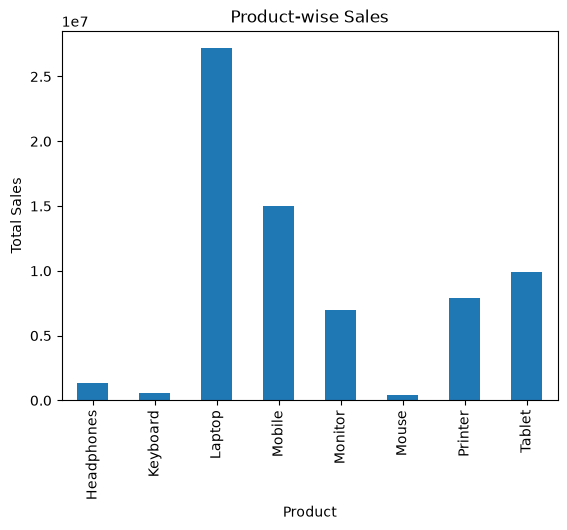

In [5]:
product_sales = df.groupby('Product')['Sales'].sum()

print(product_sales)

product_sales.plot(kind='bar')
plt.title('Product-wise Sales')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.show()

## Region-wise Sales Analysis

Region
East     17499400
North    15898000
South    20360900
West     15499800
Name: Sales, dtype: int64


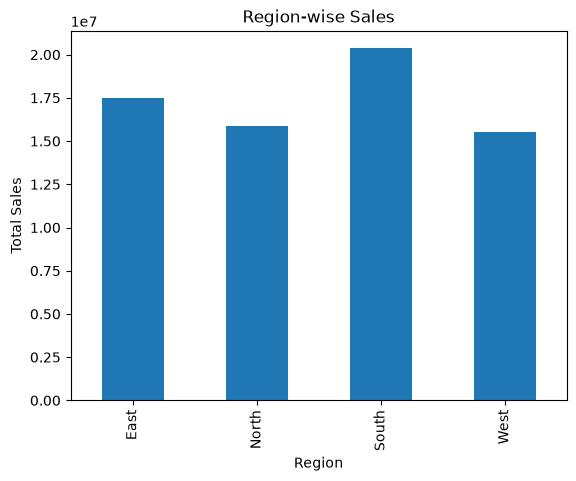

In [6]:
region_sales = df.groupby('Region')['Sales'].sum()

print(region_sales)

region_sales.plot(kind='bar')
plt.title('Region-wise Sales')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

## Category-wise Sales Analysis

Category
Accessories     1004600
Electronics    60333500
Office          7920000
Name: Sales, dtype: int64


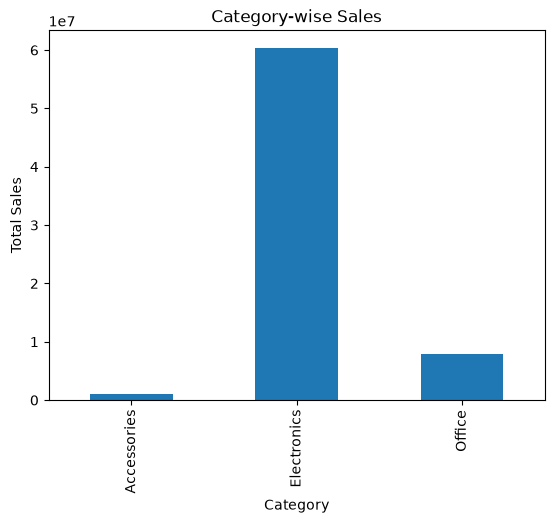

In [7]:
category_sales = df.groupby('Category')['Sales'].sum()

print(category_sales)

category_sales.plot(kind='bar')
plt.title('Category-wise Sales')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

## Product-wise Profit Analysis

Product
Headphones     226274.260
Keyboard       100555.375
Laptop        4571867.890
Mobile        2606245.900
Monitor       1132560.920
Mouse           76425.255
Printer       1349652.200
Tablet        1539092.340
Name: Profit, dtype: float64


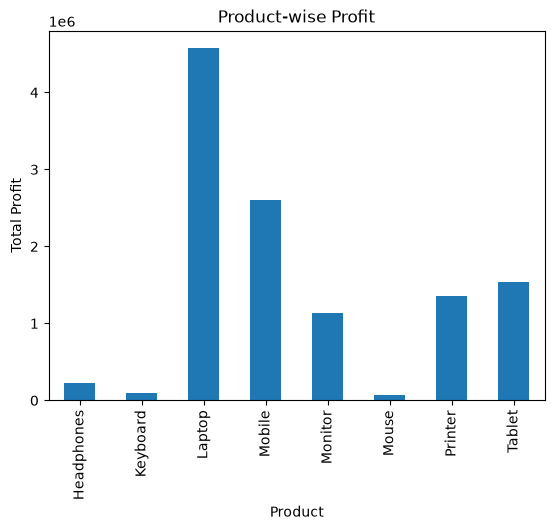

In [8]:
product_profit = df.groupby('Product')['Profit'].sum()

print(product_profit)

product_profit.plot(kind='bar')
plt.title('Product-wise Profit')
plt.xlabel('Product')
plt.ylabel('Total Profit')
plt.show()

## Monthly Sales Trend

Date
2025-01    4834400
2025-02    5813900
2025-03    4006400
2025-04    5498000
2025-05    7362300
2025-06    7157400
2025-07    4623500
2025-08    6302700
2025-09    5449200
2025-10    5126400
2025-11    5364400
2025-12    7719500
Freq: M, Name: Sales, dtype: int64


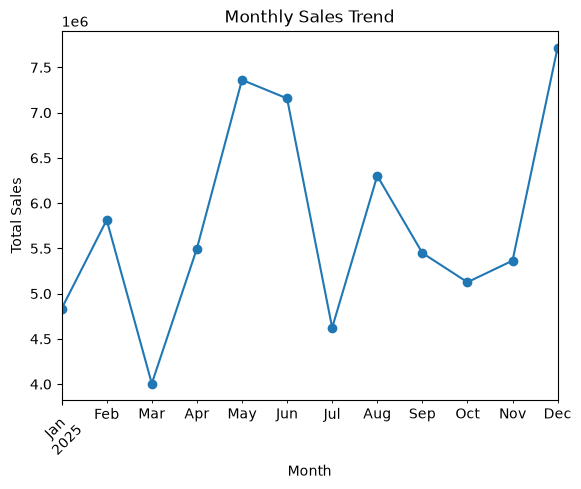

In [9]:
df['Date'] = pd.to_datetime(df['Date'])

monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Sales'].sum()

print(monthly_sales)

monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

## Correlation Analysis

            Quantity  Unit_Price     Sales    Profit
Quantity    1.000000   -0.016967  0.412916  0.380957
Unit_Price -0.016967    1.000000  0.800379  0.740412
Sales       0.412916    0.800379  1.000000  0.927392
Profit      0.380957    0.740412  0.927392  1.000000


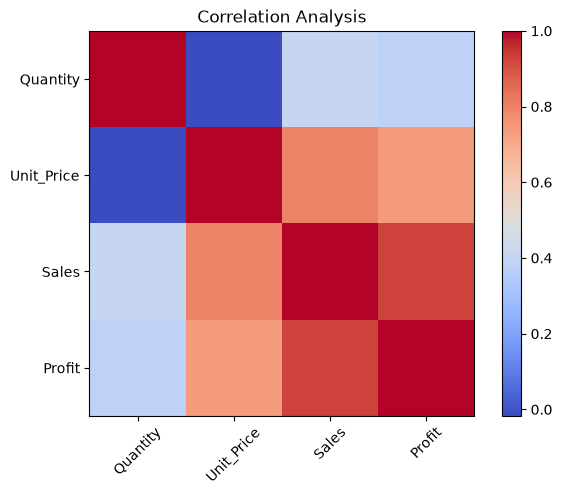

In [10]:
correlation = df[['Quantity', 'Unit_Price', 'Sales', 'Profit']].corr()

print(correlation)

plt.figure(figsize=(7, 5))
plt.imshow(correlation, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(4), correlation.columns, rotation=45)
plt.yticks(range(4), correlation.columns)
plt.title('Correlation Analysis')
plt.show()

## Outlier Analysis

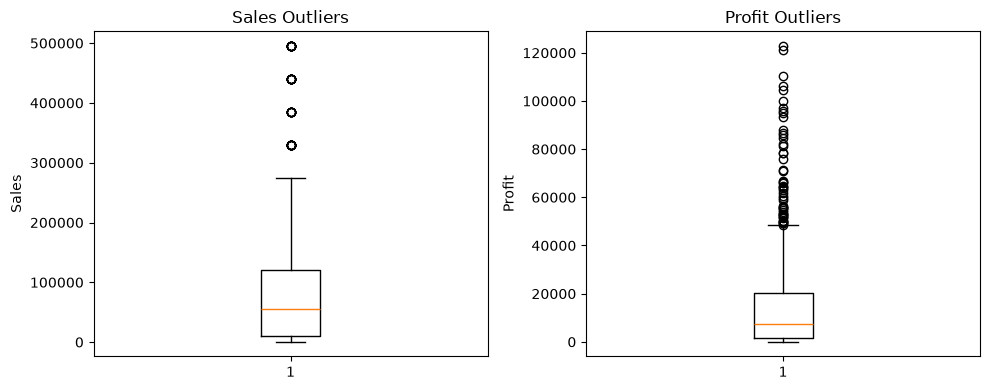

Outliers:
Sales     43
Profit    50
dtype: int64


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot(df['Sales'])
axes[0].set_title('Sales Outliers')
axes[0].set_ylabel('Sales')

axes[1].boxplot(df['Profit'])
axes[1].set_title('Profit Outliers')
axes[1].set_ylabel('Profit')

plt.tight_layout()
plt.show()

Q1 = df[['Sales', 'Profit']].quantile(0.25)
Q3 = df[['Sales', 'Profit']].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[['Sales', 'Profit']] < (Q1 - 1.5 * IQR)) |
            (df[['Sales', 'Profit']] > (Q3 + 1.5 * IQR))).sum()

print("Outliers:")
print(outliers)

## EDA Findings

In [12]:
print("Total Sales:", df['Sales'].sum())
print("Total Profit:", df['Profit'].sum())
print("Best Selling Product:", product_sales.idxmax())
print("Best Region:", region_sales.idxmax())
print("Best Category:", category_sales.idxmax())
print("Most Profitable Product:", product_profit.idxmax())

Total Sales: 69258100
Total Profit: 11602674.14
Best Selling Product: Laptop
Best Region: South
Best Category: Electronics
Most Profitable Product: Laptop


## Task 5 – Data Visualizations

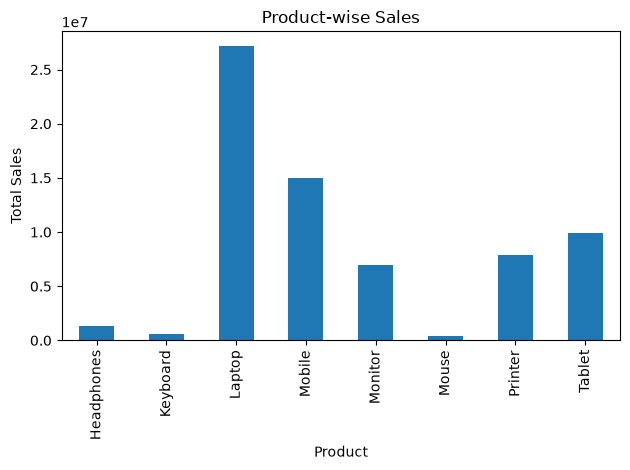

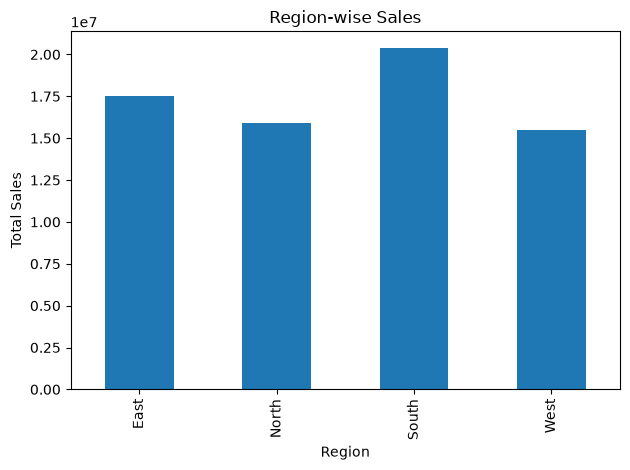

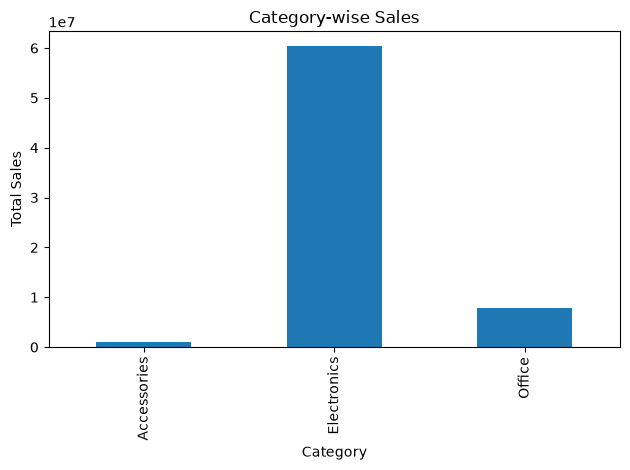

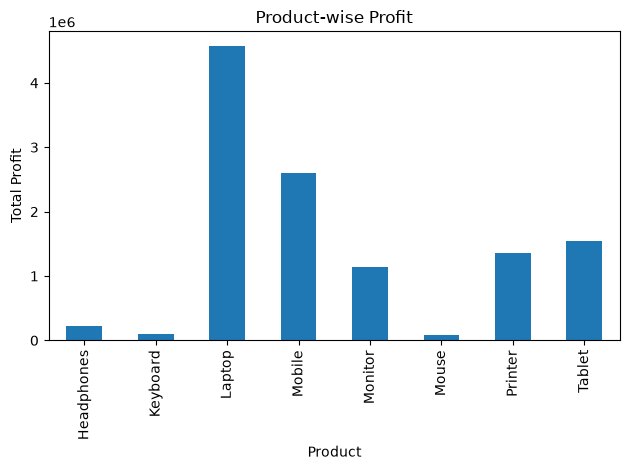

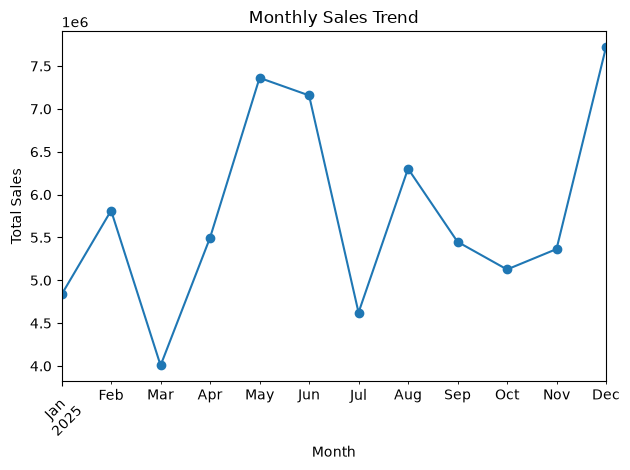

5 visualizations saved successfully!


In [13]:
import os

os.makedirs("Visualizations", exist_ok=True)

# 1. Product-wise Sales
product_sales.plot(kind='bar')
plt.title('Product-wise Sales')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('Visualizations/Product_Wise_Sales.png')
plt.show()
plt.close()

# 2. Region-wise Sales
region_sales.plot(kind='bar')
plt.title('Region-wise Sales')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('Visualizations/Region_Wise_Sales.png')
plt.show()
plt.close()

# 3. Category-wise Sales
category_sales.plot(kind='bar')
plt.title('Category-wise Sales')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('Visualizations/Category_Wise_Sales.png')
plt.show()
plt.close()

# 4. Product-wise Profit
product_profit.plot(kind='bar')
plt.title('Product-wise Profit')
plt.xlabel('Product')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.savefig('Visualizations/Product_Wise_Profit.png')
plt.show()
plt.close()

# 5. Monthly Sales Trend
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Visualizations/Monthly_Sales_Trend.png')
plt.show()
plt.close()

print("5 visualizations saved successfully!")